## **Detecção e Tratamento de Outliers**

Outliers (valores atípicos) são observações que se afastam significativamente da tendência geral ou padrão de um conjunto de dados. Essas observações podem ser valores muito altos ou muito baixos em relação à média, ou outras medidas de centralidade e dispersão dos dados.

### **Como ocorrem os outliers**

 - Erros de medição (falhas em sensores, instrumentos ou coleta de dados);

- Erros de entrada ou processamento dos dados (erros de digitação, conversão ou importação);

- Amostragem inadequada ou amostras que não representam bem a população;

- Viés de seleção, quando o processo de coleta favorece determinados tipos de observações;

- Eventos raros, porém reais, que representam casos legítimos e podem conter informações importantes para a análise.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

In [54]:
df = pd.read_csv('datasets/autoscout24-germany-dataset.csv')
display(df.head())

,mileage,make,model,fuel,gear,offerType,price,hp,year
0,235000,BMW,316,Diesel,Manual,Used,6800,116.00,2011
1,92800,Volkswagen,Golf,Gasoline,Manual,Used,6877,122.00,2011
2,149300,SEAT,Exeo,Gasoline,Manual,Used,6900,160.00,2011
3,96200,Renault,Megane,Gasoline,Manual,Used,6950,110.00,2011
4,156000,Peugeot,308,Gasoline,Manual,Used,6950,156.00,2011


In [55]:
print(df.shape)

(46405, 9)


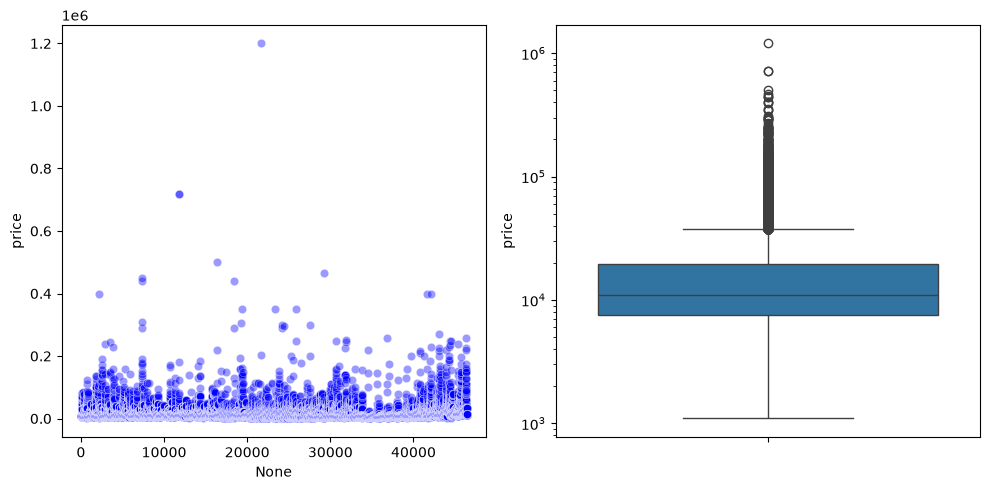

In [56]:
fig, ax = plt.subplots(1,2,figsize = (10,5))
sns.scatterplot(data=df, x=df.index, y='price', color = 'blue', alpha = 0.4, ax=ax[0])
sns.boxplot(data=df['price'],ax = ax[1])
ax[1].set_yscale('log')
plt.tight_layout()
plt.show()

In [57]:
df.describe()

,mileage,price,hp,year
count,46405.00,46405.00,46376.00,46405.00
mean,71177.86,16572.34,132.99,2016.01
std,62625.31,19304.70,75.45,3.16
min,0.00,1100.00,1.00,2011.00
25%,19800.00,7490.00,86.00,2013.00
50%,60000.00,10999.00,116.00,2016.00
75%,105000.00,19490.00,150.00,2019.00
max,1111111.00,1199900.00,850.00,2021.00


- As colunas mileage, price e hp, possuem uma grande diferença entre o terceiro quartil (75%) e o valor máximo de cada coluna (max).

- Este é um indicadivo de uma possível presença de outliers dentro do conjunto de dados.

### **Método IQR para identificar outliers**

É uma técnica estatística usada para identificar outliers em um conjunto de dados. Ele se baseia nos quartis do conjunto de dados e no intervalo interquartil (IQR), que é definido como a diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1).

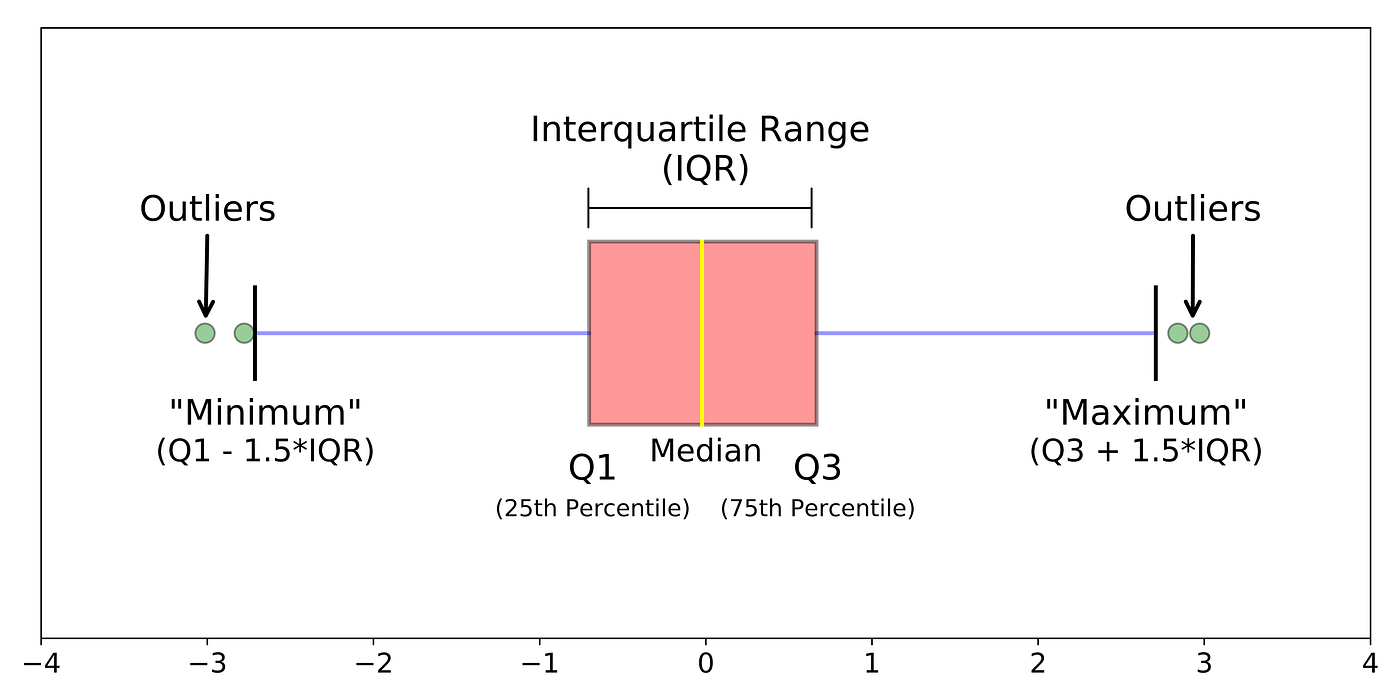

In [58]:
def detectar_outliers_iqr(data: pd.DataFrame, column: str) -> pd.DataFrame:

    arr = data[column]

    Q3 = arr.quantile(0.75)
    Q1 = arr.quantile(0.25)

    IQR = Q3 - Q1

    lim_sup = Q3 + 1.5 * IQR
    lim_inf = Q1 - 1.5 * IQR

    intervalo = ((arr < lim_inf) | (arr > lim_sup))

    outliers = arr[intervalo]

    return outliers

for col in ['mileage', 'price', 'hp']:
    print(f'Coluna: {col}')

    outliers = detectar_outliers_iqr(df, col)

    print(f'Quantidade de outliers: {len(outliers)}')
    display(outliers.head())

Coluna: mileage
Quantidade de outliers: 840


0     235000
12    427000
26    299900
44    239211
50    240000
Name: mileage, dtype: int64

Coluna: price
Quantidade de outliers: 3233


120    37931
143    37700
144    37950
145    39444
146    42480
Name: price, dtype: int64

Coluna: hp
Quantidade de outliers: 3007


119   252.00
120   333.00
135   272.00
142   300.00
144   320.00
Name: hp, dtype: float64

### **Método do Desvio Padrão**

Essa técnica é baseada no cálculo da média e do desvio padrão dos dados, e considera como outlier qualquer valor que esteja a uma certa distância (em desvios padrão) da média.


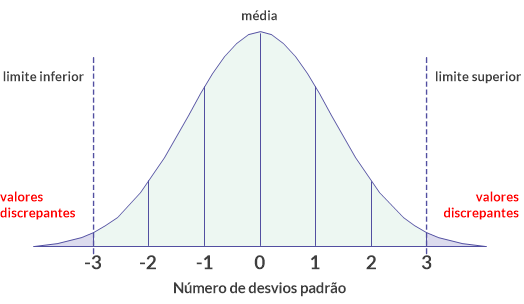

In [59]:
def detectar_outliers_std(data: pd.DataFrame, column: str) -> pd.DataFrame:

    arr = data[column]

    desvio_padrao = arr.std()
    media = arr.mean()

    intervalo = ((arr < media - 3 * desvio_padrao) | (arr > media + 3 * desvio_padrao))

    outliers = arr[intervalo]

    return outliers

for col in ['mileage', 'price', 'hp']:
    print(f'Coluna: {col}')

    outliers = detectar_outliers_std(df, col)

    print(f'Quantidade de outliers: {len(outliers)}')
    display(outliers.head())

Coluna: mileage
Quantidade de outliers: 470


12     427000
26     299900
84     352000
253    261000
304    285000
Name: mileage, dtype: int64

Coluna: price
Quantidade de outliers: 614


190    81890
191    81890
192    81890
193    83890
384    74990
Name: price, dtype: int64

Coluna: hp
Quantidade de outliers: 987


151   370.00
175   367.00
176   367.00
177   400.00
178   400.00
Name: hp, dtype: float64

### **Tipos de Tratamento**

O tratamento de outliers (valores atípicos) envolve técnicas de identificação, remoção ou substituição para evitar que valores fora da curva causem anomalias ou enviesem os resultados de modelos de Machine Learning.

Antes de qualquer tratamento, é ideal uma análise pra investigar a origem do outliers.

### **Principais abordagens de tratamento**

- Remoção de Outliers;

- Substituição;

- Transformações.